In [1]:
import os
os.chdir(r'C:\Users\johnpaul\fraudguard-africa')
print(os.getcwd())

C:\Users\johnpaul\fraudguard-africa


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Load data again (we'll make this cleaner later)
df = pd.read_csv('data/PS_20174392719_1491204439457_log.csv')

# Re-apply feature engineering
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['oldbalanceDest'] - df['newbalanceDest']
df['amount_to_oldbalance_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)
df['amount_to_newbalance_ratio'] = df['amount'] / (df['newbalanceOrig'] + 1)
df['hour'] = df['step'] % 24
df['is_night'] = df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)

df = pd.get_dummies(df, columns=['type'], prefix='type', drop_first=True)
orig_freq = df['nameOrig'].value_counts()
df['orig_transaction_freq'] = df['nameOrig'].map(orig_freq)
df['high_risk_transaction'] = ((df['type_CASH_OUT'] == 1) & (df['amount'] > 100000)).astype(int)

In [3]:
# Prepare X and y
drop_cols = ['nameOrig', 'nameDest', 'isFlaggedFraud', 'step']
feature_cols = [col for col in df.columns if col not in drop_cols + ['isFraud']]

X = df[feature_cols]
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# ====================== TRAIN XGBOOST MODEL ======================
print("Training XGBoost Model...\n")

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='aucpr'   # Important for imbalanced data
)

model.fit(X_train_scaled, y_train)

Training XGBoost Model...



,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


In [5]:
# ====================== EVALUATION ======================
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Precision-Recall AUC (very important for fraud)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc:.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      0.84      0.90      1643

    accuracy                           1.00   1272524
   macro avg       0.98      0.92      0.95   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC Score: 0.9986
PR-AUC Score: 0.9628


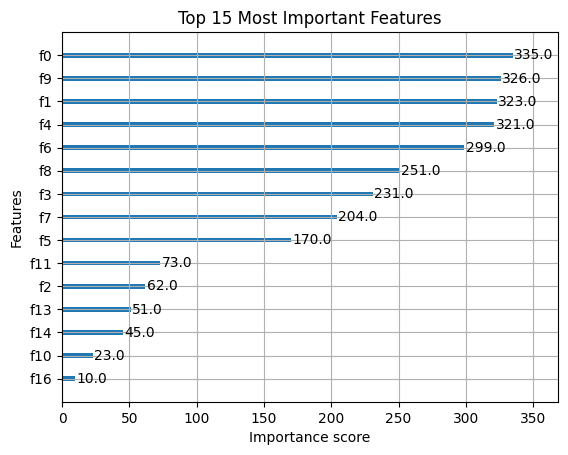

                       feature  importance
5            balance_diff_orig    0.301845
4               newbalanceDest    0.232302
8   amount_to_newbalance_ratio    0.104799
1                oldbalanceOrg    0.102185
2               newbalanceOrig    0.098304
14               type_TRANSFER    0.051327
11               type_CASH_OUT    0.043447
7   amount_to_oldbalance_ratio    0.032861
9                         hour    0.008932
6            balance_diff_dest    0.008628


In [6]:
# Feature Importance
import matplotlib.pyplot as plt

xgb.plot_importance(model, max_num_features=15)
plt.title('Top 15 Most Important Features')
plt.show()

# Print top 10 features
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(10))